
# SARS-CoV-2 Genome: Download & Analysis (Interactive Notebook)

This notebook downloads the SARS-CoV-2 (COVID-19) reference genome and performs basic exploratory analyses:

* Download the reference FASTA (RefSeq NC_045512) from NCBI
* Parse viral sequences and validate data integrity
* Summary statistics (lengths, global GC%)
* **Adaptive plotting:** window-based GC% histograms tailored for viral genomes
* Base composition & GC skew analysis
* Windowed GC% profile along the genome
* k-mer frequencies analysis (configurable k)
* Simple ORF scan (naïve start/stop scan in all 6 frames)
* Complementary Dinucleotide Odds Ratio (Rho statistic) & CDS translation
* Histograms and line plots


In [17]:

# If running on a clean environment, uncomment to install Biopython
# %pip install biopython --quiet

import os
import gzip
import io
import math
import urllib.request
from pathlib import Path
from collections import Counter, defaultdict

from Bio import SeqIO
from Bio.Seq import Seq

import numpy as np
import matplotlib.pyplot as plt

# Matplotlib defaults (publication-friendly but simple)
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = True

# 1. Definimos el número de acceso de SARS-CoV-2
ACCESSION = "NC_045512"

# 2. Creamos el directorio de datos para el virus
DATA_DIR = Path("data_covd")
DATA_DIR.mkdir(exist_ok=True, parents=True)

# 3. URLs de descarga directa desde NCBI (Corregidas sin comillas dobles)
NCBI_FASTA_URL = f"https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id={ACCESSION}&rettype=fasta&retmode=text"
URL_CDS = f"https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id={ACCESSION}&rettype=fasta_cds_na&retmode=text"

# 4. Rutas locales de almacenamiento para el genoma y las secuencias codificantes
LOCAL_FASTA = DATA_DIR / f"{ACCESSION}_genome.fasta"
LOCAL_CDS = DATA_DIR / f"{ACCESSION}_cds.fasta"

print("Data directory:", DATA_DIR.resolve())


Data directory: C:\Users\FAMIL\data_covd



## 1) Download the Human SARS‑CoV‑2  reference genome

This cell downloads the RefSeq FASTA file (if not already cached) from NCBI FTP.


In [18]:

def download_if_needed(url: str, dst: Path):
    if dst.exists():
        print(f"✅ Ya se encuentra descargado: {dst.name}")
        return
    print(f"⬇️ Descargando desde NCBI: {dst.name} ...")
    urllib.request.urlretrieve(url, dst)
    print(f"✅ Guardado con éxito")

# 1. Descargamos el genoma completo de SARS-CoV-2
download_if_needed(NCBI_FASTA_URL, LOCAL_FASTA)

# 2. Descargamos las secuencias codificantes (CDS) para el análisis de proteínas
download_if_needed(URL_CDS, LOCAL_CDS)

⬇️ Descargando desde NCBI: NC_045512_genome.fasta ...
✅ Guardado con éxito
⬇️ Descargando desde NCBI: NC_045512_cds.fasta ...
✅ Guardado con éxito



## 2) Load sequences

We parse the FASTA to get one or more sequences (chromosome, plasmids).

In [19]:

# Cargamos el archivo del genoma usando Biopython
records = list(SeqIO.parse(str(LOCAL_FASTA), "fasta"))
assert len(records) > 0, "No se cargaron secuencias. Revisa la descarga."

print(f"Se cargó {len(records)} secuencia(s) de SARS-CoV-2.")
for i, rec in enumerate(records, 1):
    desc = rec.description[:80] + ("..." if len(rec.description) > 80 else "")
    print(f"{i:>2}. {rec.id} | longitud={len(rec.seq):,} pb | {desc}")


Se cargó 1 secuencia(s) de SARS-CoV-2.
 1. NC_045512.2 | longitud=29,903 pb | NC_045512.2 Severe acute respiratory syndrome coronavirus 2 isolate Wuhan-Hu-1, ...



## 3) Basic statistics

We compute sequence lengths, total length, GC content, and N50. 

In [20]:

def gc_content(seq: str) -> float:
    s = seq.upper()
    gc = s.count("G") + s.count("C")
    atgc = s.count("A") + s.count("T") + s.count("G") + s.count("C")
    return (gc / atgc * 100.0) if atgc else float("nan")
lengths = np.array([len(r.seq) for r in records], dtype=np.int64)
total_length = int(lengths.sum())

gc_all = gc_content("".join(str(r.seq) for r in records))

genome_seq = str(records[0].seq).upper()
total_length = len(genome_seq)
gc_total = gc_content(genome_seq)

stats = {
    "num_sequences": len(records),
    "total_length": total_length,
    "GC_percent_total": gc_total,
}

print("=== ESTADÍSTICAS BÁSICAS DEL GENOMA DE SARS-CoV-2 ===")
for k, v in stats.items():
    print(f"{k}: {v}")

=== ESTADÍSTICAS BÁSICAS DEL GENOMA DE SARS-CoV-2 ===
num_sequences: 1
total_length: 29903
GC_percent_total: 37.97277865097147



### Adaptive histogram

- If multiple sequences/contigs are present, we show the contig length histogram.
- If only one sequence is present (typical for *E. coli* K-12), we show a histogram of windowed GC% values instead.


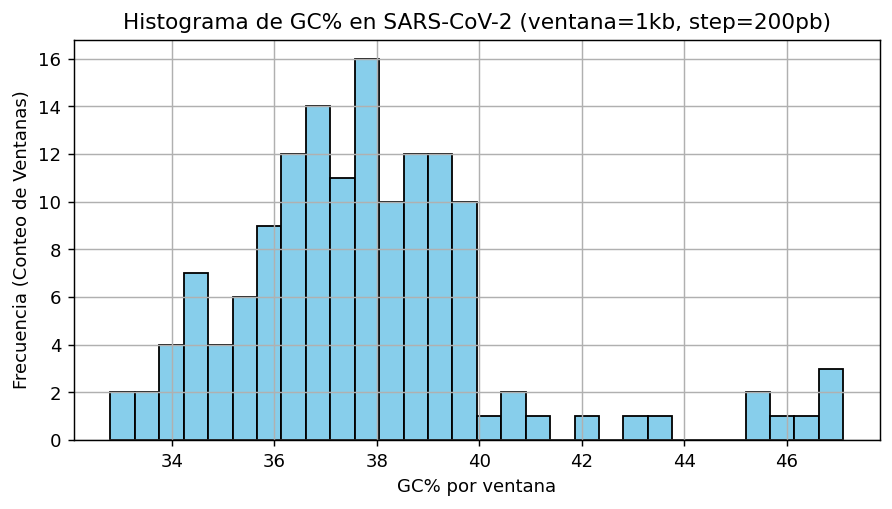

In [21]:

import matplotlib.pyplot as plt
import numpy as np

# 1.- modificación para el covid 
def sliding_gc_content(seq: str, window: int = 1000, step: int = 200):
    gc_vals = []
    centers = []
    for i in range(0, len(seq) - window + 1, step):
        w = seq[i:i+window]
        s = w.upper()
        gc = (s.count("G") + s.count("C"))
        atgc = (s.count("A") + s.count("T") + s.count("G") + s.count("C"))
        gc_percent = (gc/atgc*100.0) if atgc else float("nan")
        gc_vals.append(gc_percent)
        centers.append(i + window//2)
    return np.array(centers), np.array(gc_vals)

# 2. Calculamos las ventanas sobre la secuencia global de COVID 
centers, gc_vals = sliding_gc_content(genome_seq, window=1000, step=200)

# 3. Graficamos el Histograma de GC%
plt.figure(figsize=(8, 4))
plt.hist(gc_vals[~np.isnan(gc_vals)], bins=30, color="skyblue", edgecolor="black")
plt.xlabel("GC% por ventana")
plt.ylabel("Frecuencia (Conteo de Ventanas)")
plt.title("Histograma de GC% en SARS-CoV-2 (ventana=1kb, step=200pb)")
plt.show()


## 4) Base composition and GC skew

We compute per-base composition on the concatenated genome and show a simple GC skew profile:

- GC skew = (G - C) / (G + C) in a sliding window


In [22]:

from collections import Counter

counts = Counter(genome_seq)
counts_dict = {b: counts.get(b, 0) for b in ["A", "C", "G", "T", "N"]}

print("=== RECUENTO Y PORCENTAJE DE NUCLEÓTIDOS (SARS-CoV-2) ===")
for base, num in counts_dict.items():
    pct = (num / total_length) * 100 if total_length > 0 else 0
    print(f"Base {base}: {num:,} pb ({pct:.2f}%)")


=== RECUENTO Y PORCENTAJE DE NUCLEÓTIDOS (SARS-CoV-2) ===
Base A: 8,954 pb (29.94%)
Base C: 5,492 pb (18.37%)
Base G: 5,863 pb (19.61%)
Base T: 9,594 pb (32.08%)
Base N: 0 pb (0.00%)


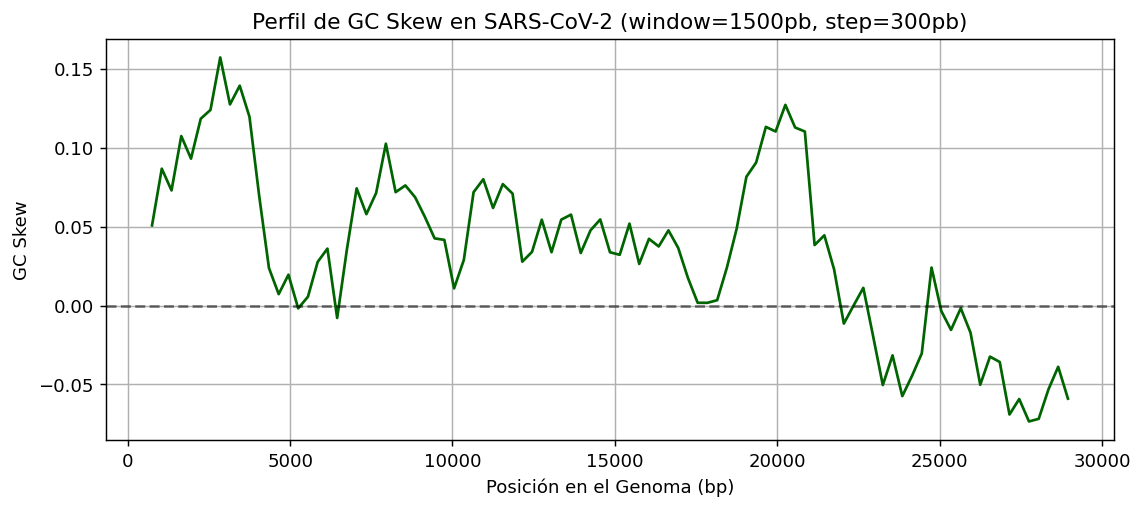

In [23]:
def sliding_gc_skew(seq: str, window: int = 1500, step: int = 300):
    skew_vals = []
    pos = []
    for i in range(0, len(seq) - window + 1, step):
        w = seq[i:i+window]
        g = w.count("G")
        c = w.count("C")
        denom = g + c
        skew = (g - c) / denom if denom else 0.0
        skew_vals.append(skew)
        pos.append(i + window//2)
    return np.array(pos), np.array(skew_vals)


pos, skew = sliding_gc_skew(genome_seq, window=1500, step=300)

# Graficamos el perfil lineal de GC Skew
plt.figure(figsize=(10, 4))
plt.plot(pos, skew, color="darkgreen", linewidth=1.5)
plt.axhline(0, color="black", linestyle="--", alpha=0.5)
plt.xlabel("Posición en el Genoma (bp)")
plt.ylabel("GC Skew")
plt.title("Perfil de GC Skew en SARS-CoV-2 (window=1500pb, step=300pb)")
plt.show()



## 5) Windowed GC% profile (line)


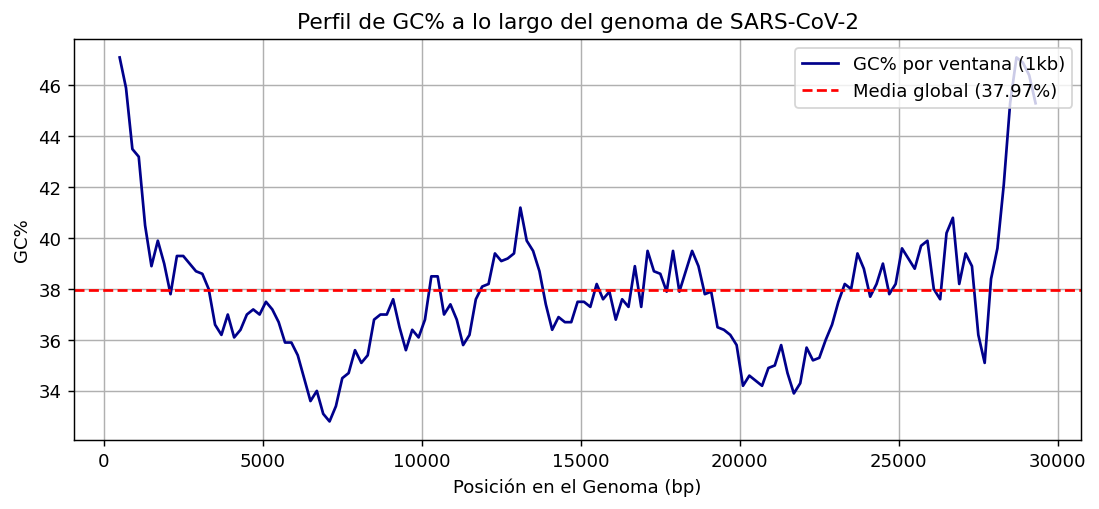

In [24]:

plt.figure(figsize=(10, 4))
plt.plot(centers, gc_vals, color="darkblue", linewidth=1.5, label="GC% por ventana (1kb)")
plt.axhline(gc_total, color="red", linestyle="--", linewidth=1.5, label=f"Media global ({gc_total:.2f}%)")

plt.xlabel("Posición en el Genoma (bp)")
plt.ylabel("GC%")
plt.title("Perfil de GC% a lo largo del genoma de SARS-CoV-2")
plt.legend(loc="upper right")
plt.show()



## 6) k-mer frequencies

Count canonical k-mers (treating a k-mer and its reverse complement as the same). Adjust `k` as needed.


In [25]:

from Bio.Seq import Seq

def revcomp(s: str) -> str:
    return str(Seq(s).reverse_complement())

def canonical_kmer(s: str) -> str:
    rc = revcomp(s)
    return min(s, rc)

def kmer_counts(seq: str, k: int = 2):
    seq = seq.upper()
    valid = set("ACGT")
    cnt = Counter()
    for i in range(len(seq) - k + 1):
        kmer = seq[i:i+k]
        if set(kmer) <= valid:
            cnt[canonical_kmer(kmer)] += 1
    return cnt

k = 4  # change k here if desired
kcnt = kmer_counts(genome, k=k)
# Show top 20
top20 = sorted(kcnt.items(), key=lambda x: x[1], reverse=True)[:20]
top20


[('CAGC', 74048),
 ('AAAA', 70767),
 ('CGCC', 69673),
 ('CCAG', 68043),
 ('GCCA', 62985),
 ('CGGC', 57523),
 ('CTGC', 57415),
 ('CCGC', 57096),
 ('ATCA', 55174),
 ('GGCA', 55097),
 ('GAAA', 54810),
 ('GCAA', 54367),
 ('AGCG', 53428),
 ('CATC', 52712),
 ('ACGC', 52207),
 ('TGAA', 51762),
 ('AAAT', 51593),
 ('GCGA', 50921),
 ('CGCA', 50851),
 ('AAAC', 50477)]

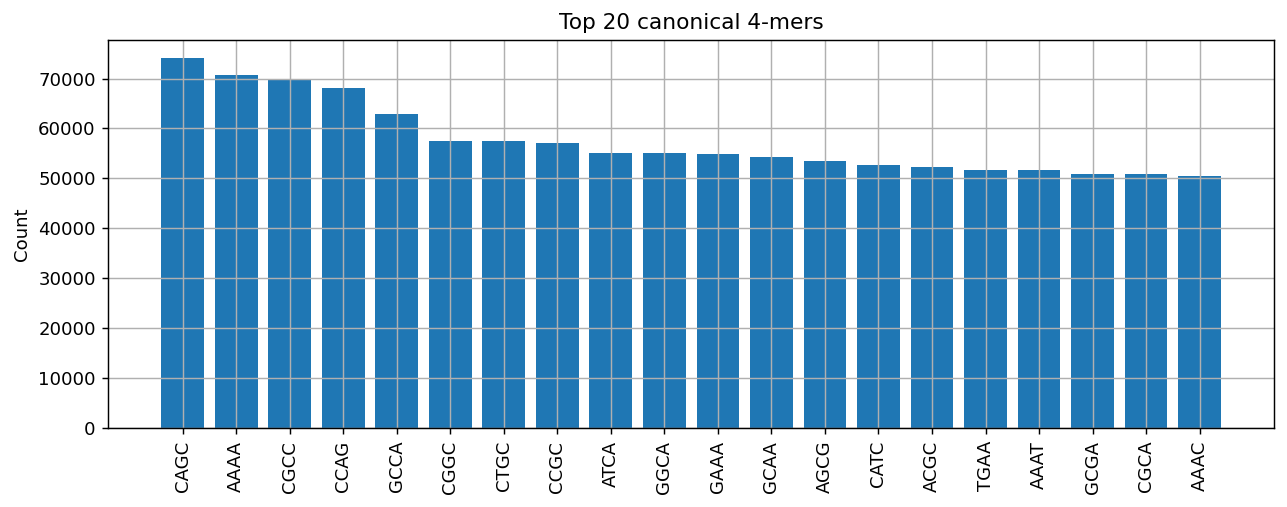

In [26]:

labels, values = zip(*sorted(kcnt.items(), key=lambda x: x[1], reverse=True)[:20])
x = np.arange(len(labels))

plt.figure(figsize=(10,4))
plt.bar(x, values)
plt.xticks(x, labels, rotation=90)
plt.ylabel("Count")
plt.title(f"Top {len(labels)} canonical {k}-mers")
plt.tight_layout()
plt.show()



## 7) Simple ORF scan (6 frames)

This is a **naïve** ORF finder scanning all six frames using typical bacterial start/stop codons:
- Starts: ATG, GTG, TTG
- Stops: TAA, TAG, TGA

Use this for exploratory analysis only (not for annotation-grade calls).


In [27]:

STARTS = {"ATG","GTG","TTG"}
STOPS = {"TAA","TAG","TGA"}

def find_orfs(seq: str, min_aa_len: int = 120):
    seq = seq.upper()
    from Bio.Seq import Seq as _Seq
    def _revcomp(s): return str(_Seq(s).reverse_complement())
    rc = _revcomp(seq)
    results = []

    def scan_one(s: str, strand: int):
        n = len(s)
        i = 0
        while i <= n - 3:
            codon = s[i:i+3]
            if codon in STARTS:
                j = i + 3
                while j <= n - 3:
                    stop = s[j:j+3]
                    if stop in STOPS:
                        aa_len = (j - i) // 3
                        if aa_len >= min_aa_len:
                            if strand == +1:
                                start, end = i, j+3
                            else:
                                start_rc = n - (j+3)
                                end_rc = n - i
                                start, end = start_rc, end_rc
                            results.append({
                                "strand": strand,
                                "start": start,
                                "end": end,
                                "length_aa": aa_len
                            })
                        i = j + 3
                        break
                    j += 3
            i += 3

    scan_one(seq, +1)
    scan_one(rc, -1)
    return sorted(results, key=lambda d: (d["strand"], d["start"]))

orfs = find_orfs(genome, min_aa_len=120)
len(orfs), orfs[:3]


(1941,
 [{'strand': -1, 'start': 3511, 'end': 4162, 'length_aa': 216},
  {'strand': -1, 'start': 10642, 'end': 11356, 'length_aa': 237},
  {'strand': -1, 'start': 14515, 'end': 14926, 'length_aa': 136}])

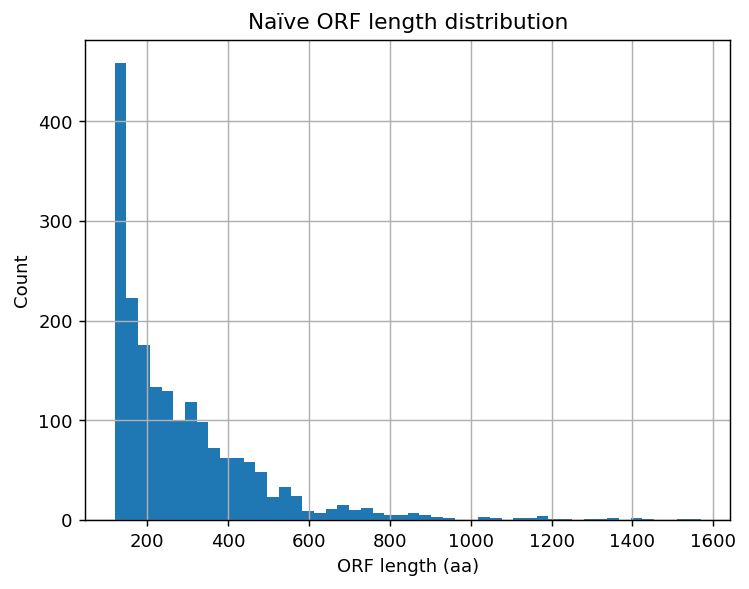

{'num_orfs_minlen120aa': 1941,
 'median_orf_len_aa': 231.0,
 'max_orf_len_aa': 1569}

In [28]:

# ORF length distribution (AA)
orf_lengths = np.array([o["length_aa"] for o in orfs])
plt.figure()
plt.hist(orf_lengths, bins=50)
plt.xlabel("ORF length (aa)")
plt.ylabel("Count")
plt.title("Naïve ORF length distribution")
plt.show()

# Quick summary
{
    "num_orfs_minlen120aa": int(len(orfs)),
    "median_orf_len_aa": float(np.median(orf_lengths)) if len(orf_lengths) else None,
    "max_orf_len_aa": int(orf_lengths.max()) if len(orf_lengths) else None,
}



### Save ORF table (optional)


In [29]:

import csv

ORF_CSV = DATA_DIR / "naive_orfs_covid_min120aa.csv"
with open(ORF_CSV, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["strand","start","end","length_aa"])
    for o in orfs:
        w.writerow([o["strand"], o["start"], o["end"], o["length_aa"]])
print(f"Saved: {ORF_CSV.resolve()}")


Saved: C:\Users\FAMIL\data_covd\naive_orfs_covid_min120aa.csv



## 8) Next steps

- Compare GC/GC-skew features to known replication origin/terminus
- Overlay annotated genes from GenBank (`.gbff`) to validate ORF calls
- Compute codon usage bias and CAI per ORF
- Add prophage or island prediction with external tools
- Run alignment-based analyses against other *E. coli* strains


In [31]:
# 9) Odds Ratio de Dinucleótidos (Estadístico $\rho$)

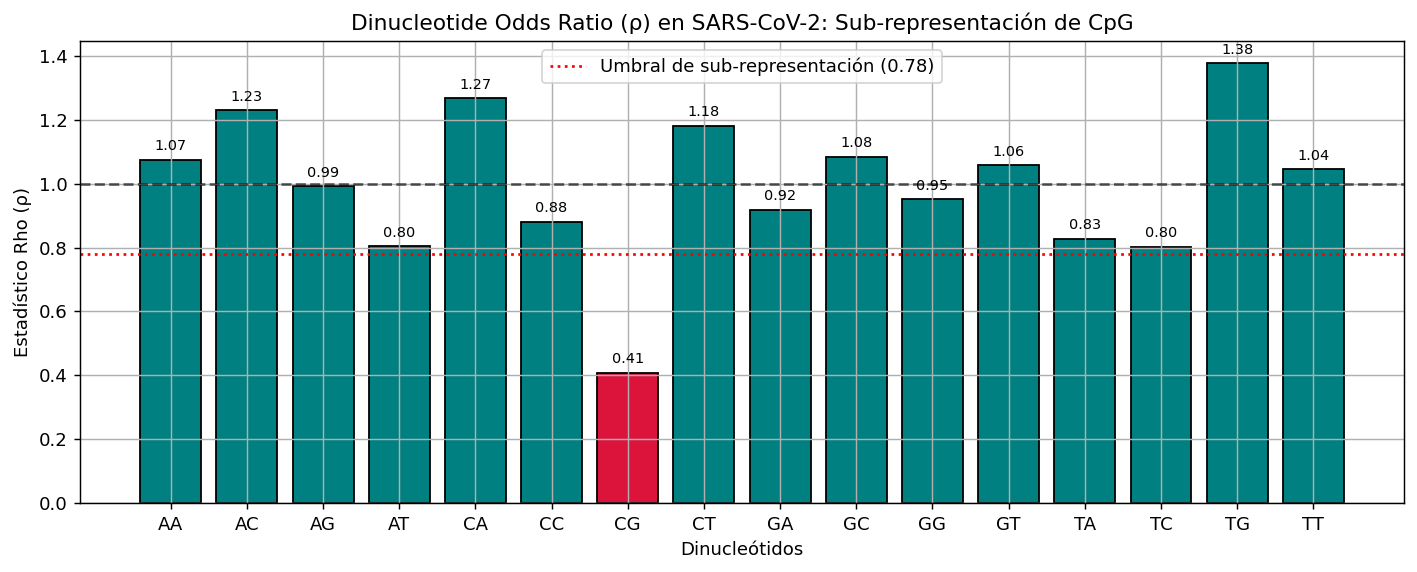

In [32]:
def calcular_odds_ratio(seq: str):
    total_bases = len(seq)
    # Frecuencias individuales f_x
    counts_mono = Counter(seq)
    f_mono = {b: counts_mono[b] / total_bases for b in ["A", "C", "G", "T"]}
    
    # Frecuencias de pares f_xy (omitimos indeterminaciones 'N')
    dinucleotidos = [seq[i:i+2] for i in range(total_bases - 1) if "N" not in seq[i:i+2]]
    total_dinu = len(dinucleotidos)
    counts_dinu = Counter(dinucleotidos)
    f_dinu = {di: counts_dinu[di] / total_dinu for di in counts_dinu}
    
    # Cálculo de Rho (ρ)
    rho = {}
    bases = ["A", "C", "G", "T"]
    for b1 in bases:
        for b2 in bases:
            di = b1 + b2
            f_observada = f_dinu.get(di, 0)
            f_esperada = f_mono[b1] * f_mono[b2]
            rho[di] = f_observada / f_esperada if f_esperada > 0 else 0
    return rho

rho_sars = calcular_odds_ratio(genome_seq)
dinu_labels = sorted(rho_sars.keys())
rho_valores = [rho_sars[di] for di in dinu_labels]

plt.figure(figsize=(11, 4.5))
colores = ["teal" if v >= 0.78 else "crimson" for v in rho_valores]
bars = plt.bar(dinu_labels, rho_valores, color=colores, edgecolor="black")
plt.axhline(1.0, color="black", linestyle="--", alpha=0.6)
plt.axhline(0.78, color="red", linestyle=":", label="Umbral de sub-representación (0.78)")

plt.ylabel("Estadístico Rho (ρ)")
plt.xlabel("Dinucleótidos")
plt.title("Dinucleotide Odds Ratio (ρ) en SARS-CoV-2: Sub-representación de CpG")
plt.legend()

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f"{yval:.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

In [33]:
# Traducción de Regiones Codificantes Reales (CDS) a Proteínas

In [34]:
import pandas as pd

cds_records = list(SeqIO.parse(str(LOCAL_CDS), "fasta"))
print(f"🧬 Se detectaron {len(cds_records)} secuencias codificantes validadas en el archivo CDS.\n")

tabla_resumen = []

# Traducir cada secuencia biológica usando el código genético estándar (table=1)
for i, cds_rec in enumerate(cds_records, 1):
    dna_seq = cds_rec.seq
    protein_seq = dna_seq.translate(table=1, to_stop=False)
    
    tabla_resumen.append({
        "ID_NCBI": cds_rec.id,
        "Longitud_Nucleótidos": len(dna_seq),
        "Longitud_Aminoácidos": len(protein_seq),
        "Secuencia_Proteica": str(protein_seq)
    })
    
    # Imprimimos las primeras 3 proteínas como una muestra en el notebook
    if i <= 3:
        print(f"Proteína {i}: {cds_rec.description[:70]}...")
        print(f"  ↳ Longitud: {len(dna_seq)} nt | {len(protein_seq)} aa")
        print(f"  ↳ Secuencia inicial: {protein_seq[:50]}...\n")

# Guardamos un reporte en formato CSV limpio en tu computadora
df_out = pd.DataFrame(tabla_resumen)
df_out.to_csv(DATA_DIR / "sars_cov2_proteinas_traducidas.csv", index=False)
print("💾 Archivo 'sars_cov2_proteinas_traducidas.csv' guardado exitosamente en tu carpeta data_covd.")

🧬 Se detectaron 12 secuencias codificantes validadas en el archivo CDS.

Proteína 1: lcl|NC_045512.2_cds_YP_009724389.1_1 [gene=ORF1ab] [locus_tag=GU280_gp...
  ↳ Longitud: 21291 nt | 7097 aa
  ↳ Secuencia inicial: MESLVPGFNEKTHVQLSLPVLQVRDVLVRGFGDSVEEVLSEARQHLKDGT...

Proteína 2: lcl|NC_045512.2_cds_YP_009725295.1_2 [gene=ORF1ab] [locus_tag=GU280_gp...
  ↳ Longitud: 13218 nt | 4406 aa
  ↳ Secuencia inicial: MESLVPGFNEKTHVQLSLPVLQVRDVLVRGFGDSVEEVLSEARQHLKDGT...

Proteína 3: lcl|NC_045512.2_cds_YP_009724390.1_3 [gene=S] [locus_tag=GU280_gp02] [...
  ↳ Longitud: 3822 nt | 1274 aa
  ↳ Secuencia inicial: MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSSVLHS...

💾 Archivo 'sars_cov2_proteinas_traducidas.csv' guardado exitosamente en tu carpeta data_covd.
